In [1]:
include("../modules/ode.jl")
using .ODE
using Plots
using Random
using LinearAlgebra

In [ ]:
function three_body_dynamics(t, u)
    G = 1.0
    m1 = 1.0
    m2 = 1.0
    m3 = 1.0

    r1 = u[1:2]
    r2 = u[3:4]
    r3 = u[5:6]

    v1 = u[7:8]
    v2 = u[9:10]
    v3 = u[11:12]

    d12 = norm(r2 - r1)
    d13 = norm(r3 - r1)
    d23 = norm(r3 - r2)

    a1 = G * m2 * (r2 - r1) / d12^3 + G * m3 * (r3 - r1) / d13^3
    a2 = G * m1 * (r1 - r2) / d12^3 + G * m3 * (r3 - r2) / d23^3
    a3 = G * m1 * (r1 - r3) / d13^3 + G * m2 * (r2 - r3) / d23^3

    du = [v1; v2; v3; a1; a2; a3]
end

three_body_dynamics (generic function with 1 method)

In [3]:
function three_body_3d(t, u)
    G = 1.0
    m = [1.0, 1.0, 1.0] # Equal masses
    
    # Extract 3D positions: u[1:3] is Body 1, u[4:6] is Body 2, u[7:9] is Body 3
    r1, r2, r3 = u[1:3], u[4:6], u[7:9]
    v1, v2, v3 = u[10:12], u[13:15], u[16:18]

    # Relative vectors and distances
    r12, r13, r23 = r2 - r1, r3 - r1, r3 - r2
    d12, d13, d23 = norm(r12), norm(r13), norm(r23)

    # Accelerations
    a1 = G * m[2] * r12 / d12^3 + G * m[3] * r13 / d13^3
    a2 = G * m[1] * (-r12) / d12^3 + G * m[3] * r23 / d23^3
    a3 = G * m[1] * (-r13) / d13^3 + G * m[2] * (-r23) / d23^3

    return [v1; v2; v3; a1; a2; a3]
end

three_body_3d (generic function with 1 method)

# 2D 3-body problem

In [4]:
p1 = [0.97000436, -0.24308753]
p2 = [-p1[1], -p1[2]]
p3 = [0.0, 0.0]

v1 = [0.4662036850, 0.4323657300]
v2 = v1
v3 = [-2 * v1[1], -2 * v1[2]]

# Flatten into a single state vector
u0 = [p1; p2; p3; v1; v2; v3]

# Simulation parameters
t_start = 0.0
t_end = 6.3259 # Approximate period of the Figure-8 orbit
steps = 1000

1000

In [5]:
t, u_solution = ODE.rk4(three_body_dynamics, t_start, t_end, steps, u0)

([0.0, 0.0063259, 0.0126518, 0.0189777, 0.0253036, 0.0316295, 0.0379554, 0.044281299999999996, 0.0506072, 0.0569331  …  6.2689669, 6.2752928, 6.2816187, 6.287944599999999, 6.2942705, 6.3005964, 6.3069223, 6.313248199999999, 6.3195741, 6.3259], [[0.97000436, -0.24308753, -0.97000436, 0.24308753, 0.0, 0.0, 0.466203685, 0.43236573, 0.466203685, 0.43236573, -0.93240737, -0.86473146], [0.9729293263438155, -0.24034643394555413, -0.9670308728820044, 0.24581646515272937, -0.005898453461811053, -0.005470031207175229, 0.4585661644833793, 0.4342471933120316, 0.4739064970970673, 0.43040196712921686, -0.9324726615804465, -0.8646491604412484], [0.9758061852878281, -0.23759368951997972, -0.9640084524472743, 0.24853271059646007, -0.011797732840553849, -0.010939021076480315, 0.4509940343221234, 0.4360489062498275, 0.48167443603617344, 0.4283533079471856, -0.9326684703582968, -0.8644022141970131], [0.978635350630639, -0.234829793279937, -0.9609366874122228, 0.2512357209484292, -0.017698663218416177, -0.

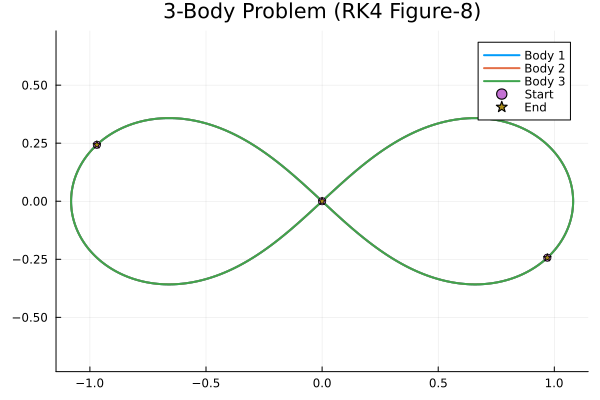

In [6]:
data = reduce(hcat, u_solution)' 

# Extract paths for plotting
x1, y1 = data[:, 1], data[:, 2]
x2, y2 = data[:, 3], data[:, 4]
x3, y3 = data[:, 5], data[:, 6]

# Plot
p = plot(title="3-Body Problem (RK4 Figure-8)", aspect_ratio=:equal, legend=:topright)
plot!(p, x1, y1, label="Body 1", linewidth=2)
plot!(p, x2, y2, label="Body 2", linewidth=2)
plot!(p, x3, y3, label="Body 3", linewidth=2)

# Mark start/end points
scatter!(p, [x1[1], x2[1], x3[1]], [y1[1], y2[1], y3[1]], label="Start", shape=:circle)
scatter!(p, [x1[end], x2[end], x3[end]], [y1[end], y2[end], y3[end]], label="End", shape=:star5)

display(p)

In [11]:
n_frames = length(t)

# --- 2. Animation Generation ---

println("Generating animation frames ($n_frames total)...")

# We use the @animate macro. Everything inside the block defines one frame.
anim = @animate for i in 1:n_frames
    # 1. Setup the blank plot frame
    # It is CRITICAL to fix xlims and ylims so the axes don't jump around.
    p = plot(aspect_ratio=:equal, 
             xlims=(-1.5, 1.5), 
             ylims=(-1.0, 1.0),
             legend=false,
             grid=false,
             bg_inside=:black, # Space look
             title="3-Body (t=$(round(t[i], digits=2)))")

    # 2. Plot the "Tails" (paths taken up to current frame i)
    # Using alpha=0.4 makes them semi-transparent
    plot!(p, data[1:i, 1], data[1:i, 2], color=:red, lw=1.5, alpha=0.4)
    plot!(p, data[1:i, 3], data[1:i, 4], color=:cyan, lw=1.5, alpha=0.4)
    plot!(p, data[1:i, 5], data[1:i, 6], color=:yellow, lw=1.5, alpha=0.4)

    # 3. Plot the current positions as markers
    # Notice we use scatter! and index only the current row [i, ...]
    scatter!(p, [data[i, 1]], [data[i, 2]], color=:red, markersize=10, markerstrokewidth=0)
    scatter!(p, [data[i, 3]], [data[i, 4]], color=:cyan, markersize=10, markerstrokewidth=0)
    scatter!(p, [data[i, 5]], [data[i, 6]], color=:yellow, markersize=10, markerstrokewidth=0)
    
    # The final line in the loop is what gets plotted for that frame
    p 
end

Generating animation frames (601 total)...


Animation("/tmp/jl_FQU9j9", ["000001.png", "000002.png", "000003.png", "000004.png", "000005.png", "000006.png", "000007.png", "000008.png", "000009.png", "000010.png"  …  "000592.png", "000593.png", "000594.png", "000595.png", "000596.png", "000597.png", "000598.png", "000599.png", "000600.png", "000601.png"])

┌ Info: Saved animation to /home/lorenzo/Repos/Notes/UniMiB/Terzo anno/Fisica Computazionale/tests/three_body_rk4.gif
└ @ Plots /home/lorenzo/.julia/packages/Plots/8ZnR3/src/animation.jl:156


Plots.AnimatedGif("/home/lorenzo/Repos/Notes/UniMiB/Terzo anno/Fisica Computazionale/tests/three_body_rk4.gif")
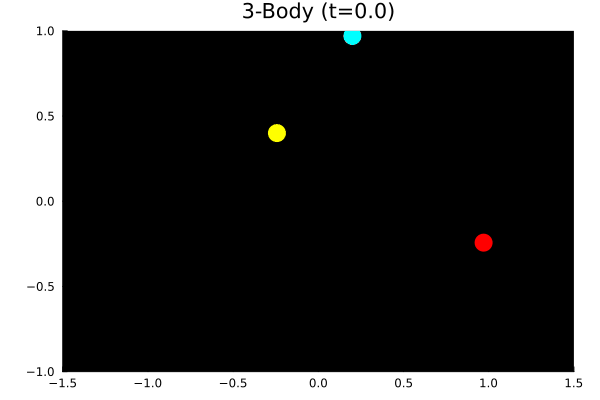

In [12]:
gif(anim, "three_body_rk4.gif", fps = 10)

# 3D 3-body problem

In [8]:
u0 = [
    0.97000436, -0.24308753, 0.2,       # Pos 1
    0.97000436, -0.24308753, 0.4,       # Pos 2
    0.0, 0.0, 0.0,                      # Pos 3
    0.4662036850, 0.4323657300, 0.1,    # Vel 1
    0.4662036850, 0.4323657300, 0.0,    # Vel 2
    -2*0.4662036850, -2*0.4323657300, 0.0   # Vel 3
]

t_span = 6.3259
steps = 600
t, u_sol = ODE.rk4(three_body_3d, 0.0, t_span, steps, u0)

data = reduce(hcat, u_sol)'

601×18 adjoint(::Matrix{Float64}) with eltype Float64:
   0.970004   -0.243088     0.2       …  -0.932407  -0.864731  0.0
   0.974869   -0.238517     0.202445     -0.914714  -0.869009  0.00529139
   0.979634   -0.233923     0.207775     -0.897283  -0.87292   0.0104475
   0.984302   -0.229307     0.216308     -0.880107  -0.876484  0.0154808
   0.988875   -0.224674     0.228709     -0.863175  -0.879719  0.0204023
   0.993359   -0.220024     0.246444  …  -0.846482  -0.882642  0.0252203
   0.997767   -0.215362     0.274045     -0.830023  -0.885267  0.02994
   1.13012    -0.237925     3.33479      -0.81385   -0.887602  0.0344979
   1.39043    -0.287711     9.41223      -0.813667  -0.887626  0.0343844
   1.65074    -0.337498    15.4897       -0.813653  -0.887627  0.0343746
   ⋮                                  ⋱   ⋮                    
 153.41      -29.3629    3558.64         -0.813645  -0.887628  0.0343691
 153.67      -29.4127    3564.71         -0.813645  -0.887628  0.0343691
 153.931    

In [ ]:
anim = @animate for i in 1:length(t)
    # Define the 3D Plot
    plot(
        title = "3-Body Problem 3D",
        camera = (45 + i/2, 20), # Rotate the camera slowly
        xlims = (-2, 2), ylims = (-2, 2), zlims = (-1, 1),
        background_color = :black,
        legend = false,
        size = (600, 600)
    )

    # Plot Trails (last 50 steps for a "comet" effect)
    start_idx = max(1, i-50)
    plot!(data[start_idx:i, 1], data[start_idx:i, 2], data[start_idx:i, 3], color=:red, alpha=0.5)
    plot!(data[start_idx:i, 4], data[start_idx:i, 5], data[start_idx:i, 6], color=:cyan, alpha=0.5)
    plot!(data[start_idx:i, 7], data[start_idx:i, 8], data[start_idx:i, 9], color=:yellow, alpha=0.5)

    # Plot Current Positions
    scatter!([data[i, 1]], [data[i, 2]], [data[i, 3]], color=:red, markersize=5)
    scatter!([data[i, 4]], [data[i, 5]], [data[i, 6]], color=:cyan, markersize=5)
    scatter!([data[i, 7]], [data[i, 8]], [data[i, 9]], color=:yellow, markersize=5)
end

┌ Info: Saved animation to /home/lorenzo/Repos/Notes/UniMiB/Terzo anno/Fisica Computazionale/tests/three_body_3d.gif
└ @ Plots /home/lorenzo/.julia/packages/Plots/8ZnR3/src/animation.jl:156


Plots.AnimatedGif("/home/lorenzo/Repos/Notes/UniMiB/Terzo anno/Fisica Computazionale/tests/three_body_3d.gif")
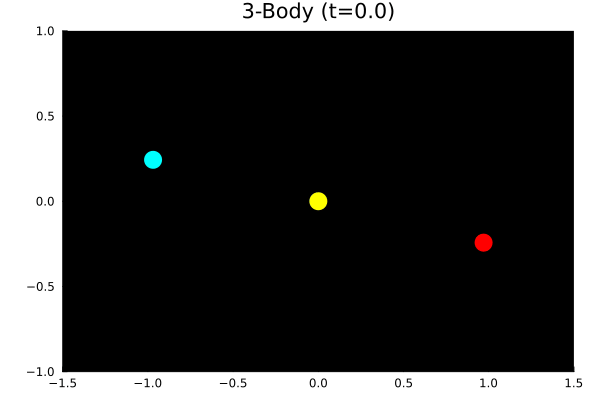

In [9]:
gif(anim, "three_body_3d.gif", fps = 30)